

# Baseline CNN Model




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [ ]:
# ====================== DATASET PATH ======================
train_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing'
test_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Training'
IMAGE_SIZE = 128

In [ ]:
# ====================== LOAD DATASET ======================
def load_data(directory):
    paths, labels = [], []
    for label in os.listdir(directory):
        for img in os.listdir(os.path.join(directory, label)):
            paths.append(os.path.join(directory, label, img))
            labels.append(label)
    return paths, labels

train_paths, train_labels = load_data(train_dir)
test_paths, test_labels = load_data(test_dir)

In [ ]:
# ====================== ENCODE LABELS ======================
classes = sorted(os.listdir(train_dir))

def encode(labels):
    return np.array([classes.index(l) for l in labels])

y_train = encode(train_labels)
y_test = encode(test_labels)

In [ ]:
# ====================== PREPROCESS IMAGES ======================
def process(paths):
    data = []
    for p in paths:
        img = load_img(p, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = img_to_array(img) / 255.0
        data.append(img)
    return np.array(data)

X_train = process(train_paths)
X_test = process(test_paths)

In [ ]:
# ====================== BUILD BASELINE CNN MODEL ======================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),                    # Increased dropout for better generalization
    Dense(len(classes), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ====================== COMPILE MODEL ======================
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# ====================== TRAIN MODEL WITH TIMING ======================
print("Starting Training Baseline CNN...\n")
start_time = time.time()

history = model.fit(X_train, y_train,
                    epochs=10,                    # Increased to 100 epochs
                    batch_size=20,
                    validation_split=0.2,
                    verbose=1)

end_time = time.time()
training_time = end_time - start_time

print(f"\nTraining Completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Starting Training Baseline CNN...

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 469ms/step - accuracy: 0.4703 - loss: 1.1619 - val_accuracy: 0.0000e+00 - val_loss: 2.6587
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 431ms/step - accuracy: 0.5852 - loss: 0.9616 - val_accuracy: 0.0000e+00 - val_loss: 2.0662
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 416ms/step - accuracy: 0.6602 - loss: 0.8004 - val_accuracy: 0.1156 - val_loss: 2.0448
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.7234 - loss: 0.6801 - val_accuracy: 0.5719 - val_loss: 1.0661
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 423ms/step - accuracy: 0.7656 - loss: 0.5853 - val_accuracy: 0.6531 - val_loss: 0.9837
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 415ms/step - accuracy: 0.7812 - loss: 0.5489 - val_accuracy: 0.7937 - val_loss: 0.6918
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 411ms/step - accuracy: 0.8258 - loss: 0.4603 - val_accuracy: 0.8062 - val_loss: 0.6720
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 433ms/step -

In [ ]:
baseline_acc = acc
baseline_f1 = f1

In [ ]:
# ====================== PREDICTION ======================
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

175/175 ━━━━━━━━━━━━━━━━━━━━ 31s 177ms/step


In [ ]:
# ====================== EVALUATION METRICS ======================
acc = accuracy_score(y_test, pred_classes)
f1 = f1_score(y_test, pred_classes, average='weighted')

print("\n" + "="*60)
print("BASELINE CNN EVALUATION RESULTS")
print("="*60)
print(f"Accuracy           : {acc:.4f} ({acc*100:.2f}%)")
print(f"F1 Score (Weighted): {f1:.4f}")
print(f"Training Time      : {training_time:.2f} seconds")
print("="*60)


BASELINE CNN EVALUATION RESULTS
Accuracy           : 0.7366 (73.66%)
F1 Score (Weighted): 0.7396
Training Time      : 344.51 seconds



Generating Confusion Matrix...


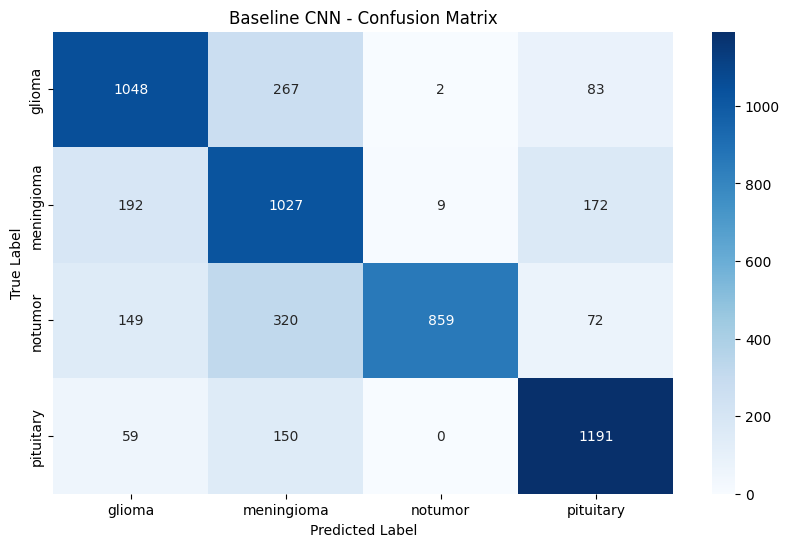

In [ ]:
# ====================== CONFUSION MATRIX ======================
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Baseline CNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# ====================== 4 REQUESTED PLOTS ======================

print("\nGenerating 4 Required Plots...")


Generating 4 Required Plots...


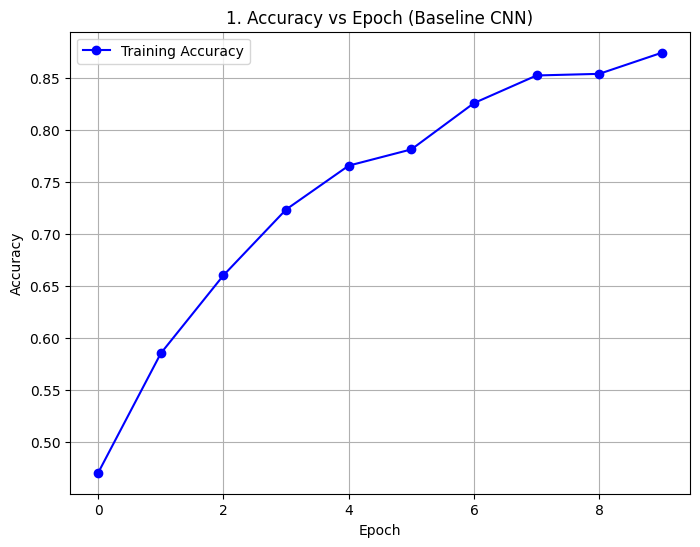

In [ ]:
# 1. Accuracy vs Epoch (Training only)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='blue')
plt.title('1. Accuracy vs Epoch (Baseline CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

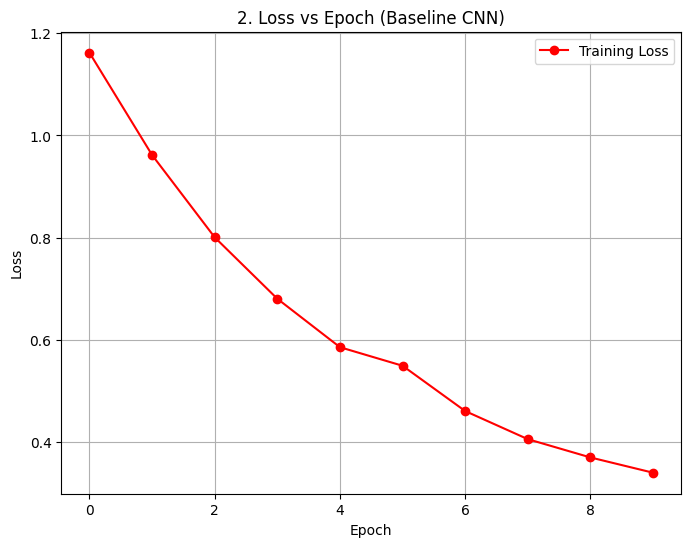

In [ ]:
# 2. Loss vs Epoch (Training only)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='red')
plt.title('2. Loss vs Epoch (Baseline CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

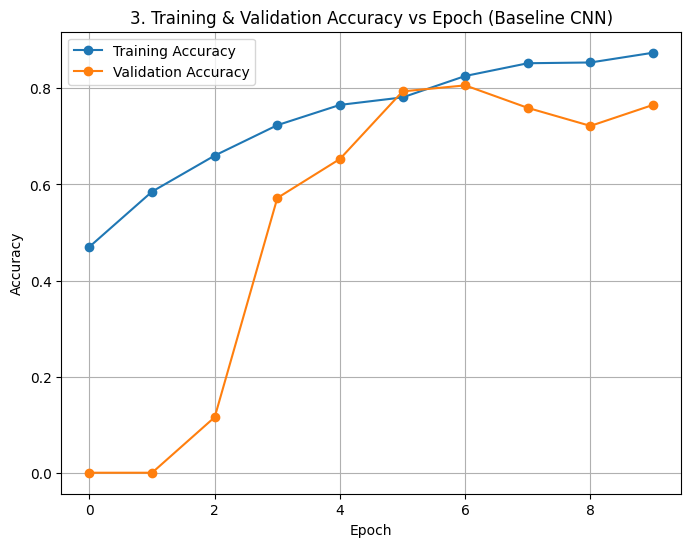

In [ ]:
# 3. Training & Validation Accuracy vs Epoch
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('3. Training & Validation Accuracy vs Epoch (Baseline CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show

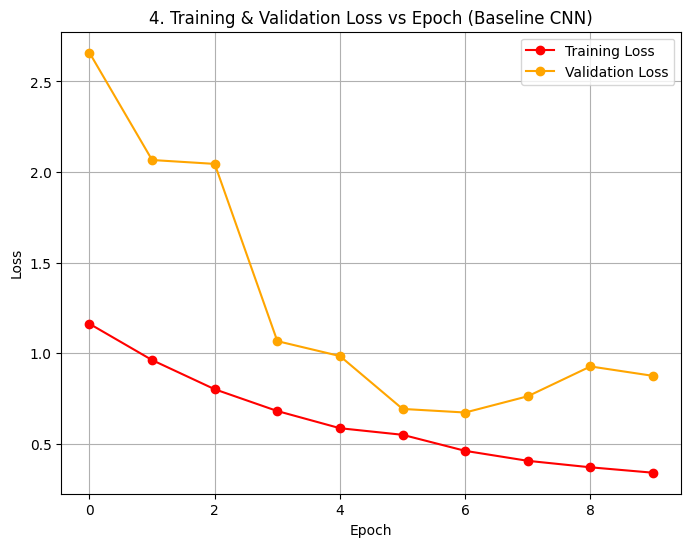

In [ ]:
# 4. Training & Validation Loss vs Epoch
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
plt.title('4. Training & Validation Loss vs Epoch (Baseline CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================== TUMOR DETECTION WITH CONFIDENCE ======================
print("\n=== Tumor Detection Examples with Confidence ===")

class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    try:
        # Load and preprocess image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Prediction
        predictions = model.predict(img_array, verbose=0)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions, axis=1)[0] * 100

        predicted_label = class_labels[predicted_class_index]

        # Display result
        plt.figure(figsize=(6, 6))
        plt.imshow(load_img(img_path))
        plt.axis('off')

        if predicted_label == 'notumor':
            result = "✅ No Tumor Detected"
        else:
            result = f"⚠️ Tumor Detected: {predicted_label.upper()}"

        plt.title(f"{result}\nConfidence: {confidence:.2f}%", fontsize=12, pad=20)
        plt.show()

    except Exception as e:
        print(f"Error processing {img_path}: {e}")


=== Tumor Detection Examples with Confidence ===


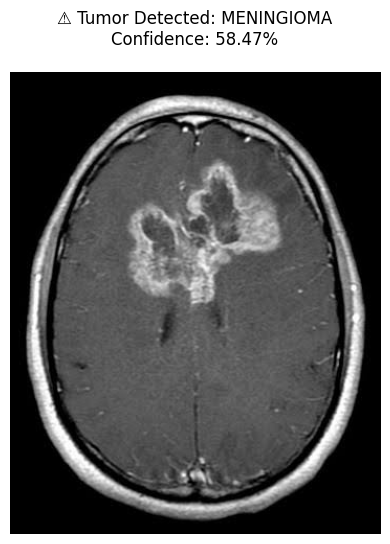

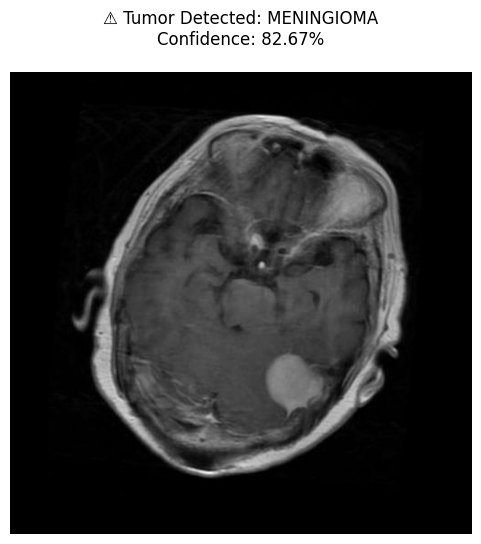

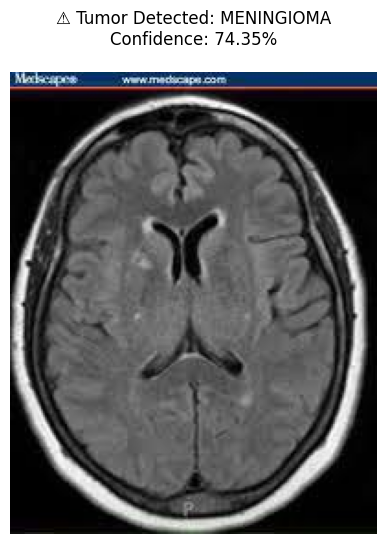

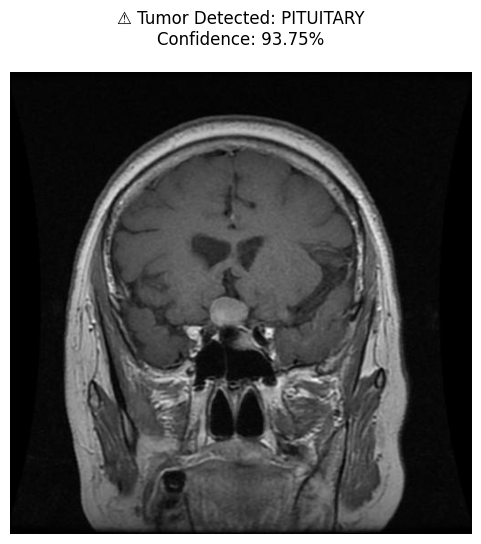

In [ ]:
# Example Test Images
example_images = [
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/glioma/Te-gl_1.jpg',
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/meningioma/Te-aug-me_1.jpg',
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/notumor/Te-no_1.jpg',
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/pituitary/Te-pi_1.jpg'
]

for path in example_images:
    detect_and_display(path, model)

In [ ]:
# Save the model
model.save('baseline_cnn_model.h5')
print("\nModel saved as 'baseline_cnn_model.h5'")


Model saved as 'baseline_cnn_model.h5'


# ResNet-50 Transfer Learning Model

In [ ]:


import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [ ]:
# ====================== DATASET PATH ======================
train_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing'
test_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Training'
IMAGE_SIZE = 128

In [ ]:
# ====================== LOAD DATASET ======================
def load_data(directory):
    paths, labels = [], []
    for label in os.listdir(directory):
        for img in os.listdir(os.path.join(directory, label)):
            paths.append(os.path.join(directory, label, img))
            labels.append(label)
    return paths, labels

train_paths, train_labels = load_data(train_dir)
test_paths, test_labels = load_data(test_dir)

In [ ]:
# ====================== ENCODE LABELS ======================
classes = sorted(os.listdir(train_dir))

def encode(labels):
    return np.array([classes.index(l) for l in labels])

y_train = encode(train_labels)
y_test = encode(test_labels)

In [ ]:
# ====================== PREPROCESS IMAGES ======================
def process(paths):
    data = []
    for p in paths:
        img = load_img(p, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = img_to_array(img) / 255.0
        data.append(img)
    return np.array(data)

X_train = process(train_paths)
X_test = process(test_paths)

In [ ]:
# ====================== BUILD RESNET50 MODEL ======================
base_model = ResNet50(weights='imagenet',
                      include_top=False,
                      input_shape=(128, 128, 3))

In [ ]:
# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# Unfreeze last 3 layers for fine-tuning
for layer in base_model.layers[-3:]:
    layer.trainable = True

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),                    # Increased dropout
    Dense(len(classes), activation='softmax')
])

In [ ]:
# ====================== COMPILE MODEL ======================
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# ====================== TRAIN MODEL WITH TIMING ======================
print("Starting Training ResNet50...\n")
start_time = time.time()

history = model.fit(X_train, y_train,
                    epochs=15,                    # Increased epochs
                    batch_size=30,
                    validation_split=0.2,
                    verbose=1)

end_time = time.time()
training_time = end_time - start_time

print(f"\nTraining Completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Starting Training ResNet50...

Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.5516 - loss: 1.0243 - val_accuracy: 0.0000e+00 - val_loss: 1.9286
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.6766 - loss: 0.7669 - val_accuracy: 0.0406 - val_loss: 1.6580
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7352 - loss: 0.6485 - val_accuracy: 0.0094 - val_loss: 1.8711
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7711 - loss: 0.5813 - val_accuracy: 0.0344 - val_loss: 1.7981
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.7852 - loss: 0.5260 - val_accuracy: 0.0938 - val_loss: 1.5853
Epoch 6/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7953 - loss: 0.5093 - val_accuracy: 0.1312 - val_loss: 1.5765
Epoch 7/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.8148 - loss: 0.4695 - val_accuracy: 0.5063 - val_loss: 1.0645
Epoch 8/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.8313 - loss: 0.4324

In [ ]:
resnet_acc = acc
resnet_f1 = f1

In [ ]:
# ====================== PREDICTION ======================
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

175/175 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step


In [ ]:
# ====================== EVALUATION METRICS ======================
acc = accuracy_score(y_test, pred_classes)
f1 = f1_score(y_test, pred_classes, average='weighted')

print("\n" + "="*60)
print("RESNET50 EVALUATION RESULTS")
print("="*60)
print(f"Accuracy           : {acc:.4f} ({acc*100:.2f}%)")
print(f"F1 Score (Weighted): {f1:.4f}")
print(f"Training Time      : {training_time:.2f} seconds")
print("="*60)


RESNET50 EVALUATION RESULTS
Accuracy           : 0.7143 (71.43%)
F1 Score (Weighted): 0.7088
Training Time      : 1138.34 seconds



Generating Confusion Matrix...


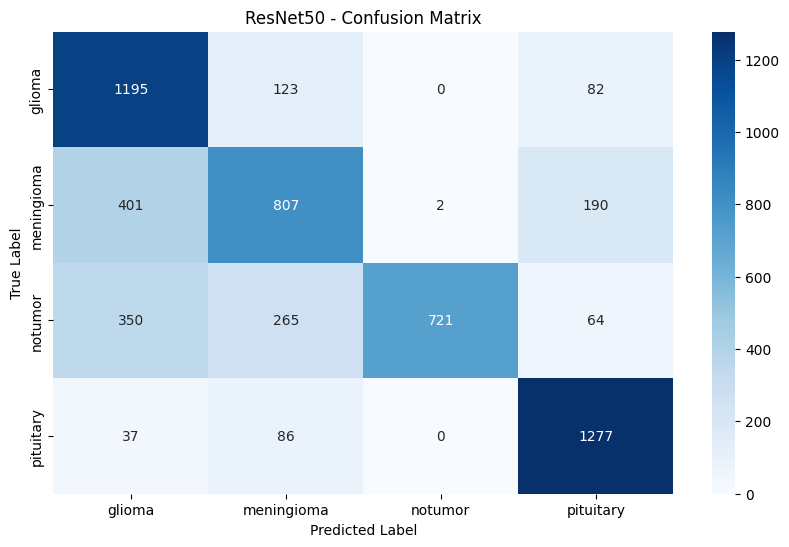

In [ ]:
# ====================== CONFUSION MATRIX ======================
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("ResNet50 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# ====================== 4 REQUESTED PLOTS ======================

print("\nGenerating 4 Required Plots...")


Generating 4 Required Plots...


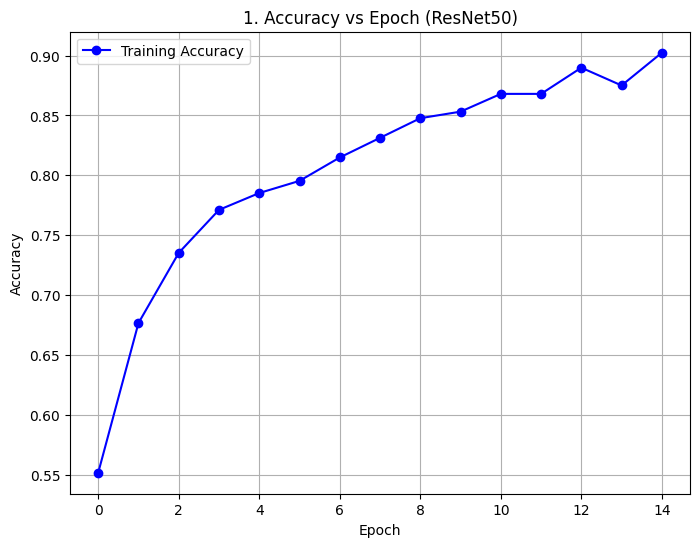

In [ ]:
# 1. Accuracy vs Epoch (Training only)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='blue')
plt.title('1. Accuracy vs Epoch (ResNet50)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

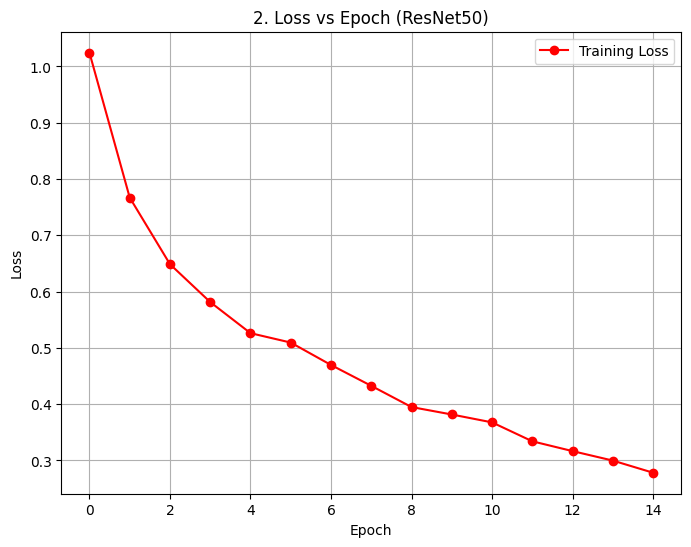

In [ ]:
# 2. Loss vs Epoch (Training only)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='red')
plt.title('2. Loss vs Epoch (ResNet50)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

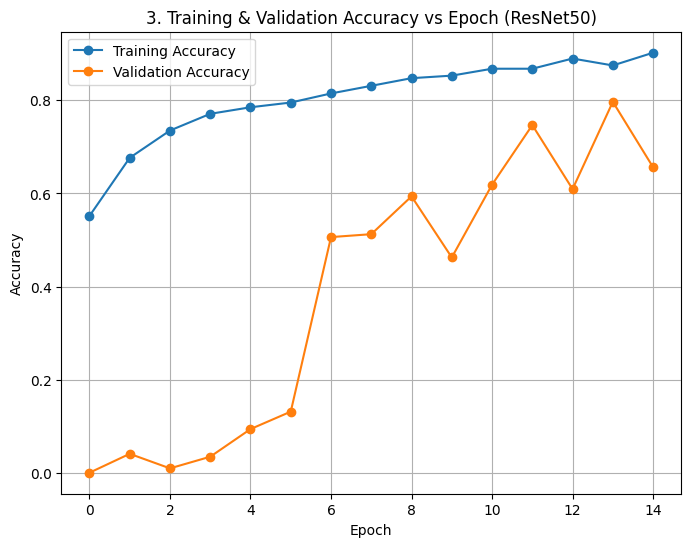

In [ ]:
# 3. Training & Validation Accuracy vs Epoch
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('3. Training & Validation Accuracy vs Epoch (ResNet50)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

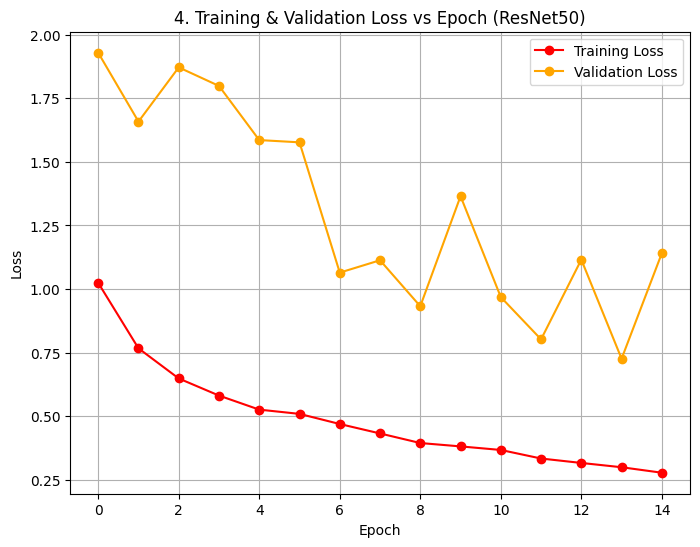

In [ ]:
# 4. Training & Validation Loss vs Epoch
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
plt.title('4. Training & Validation Loss vs Epoch (ResNet50)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================== TUMOR DETECTION WITH CONFIDENCE ======================
print("\n=== Tumor Detection Examples with Confidence ===")

class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array, verbose=0)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions, axis=1)[0] * 100

        predicted_label = class_labels[predicted_class_index]

        plt.figure(figsize=(6, 6))
        plt.imshow(load_img(img_path))
        plt.axis('off')

        if predicted_label == 'notumor':
            result = "✅ No Tumor Detected"
        else:
            result = f"⚠️ Tumor Detected: {predicted_label.upper()}"

        plt.title(f"{result}\nConfidence: {confidence:.2f}%", fontsize=12, pad=20)
        plt.show()

    except Exception as e:
        print(f"Error processing {img_path}: {e}")




=== Tumor Detection Examples with Confidence ===


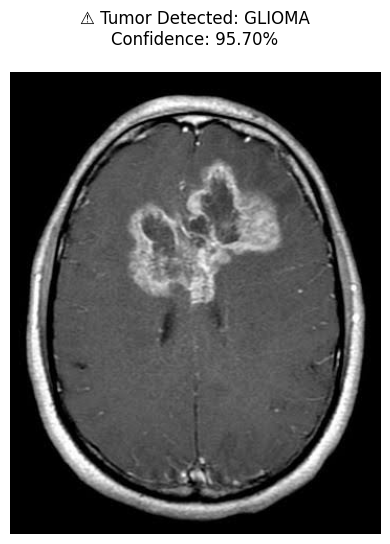

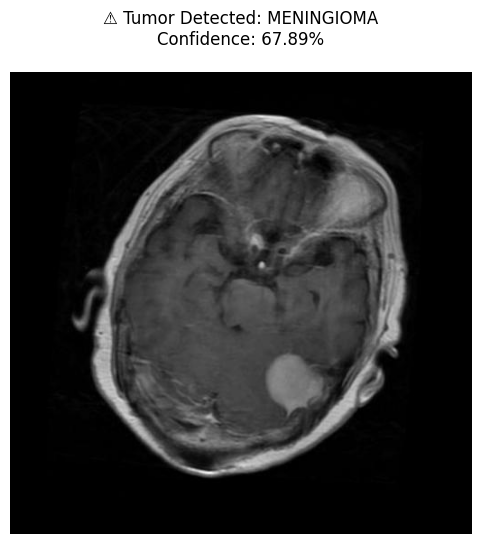

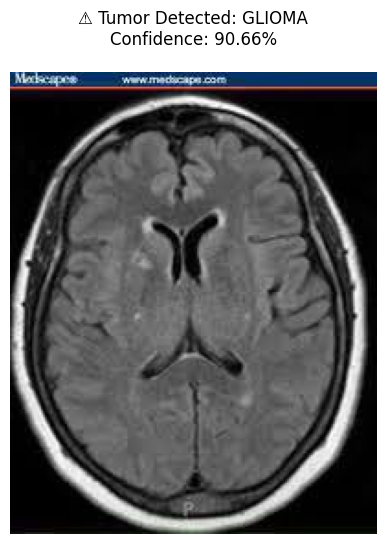

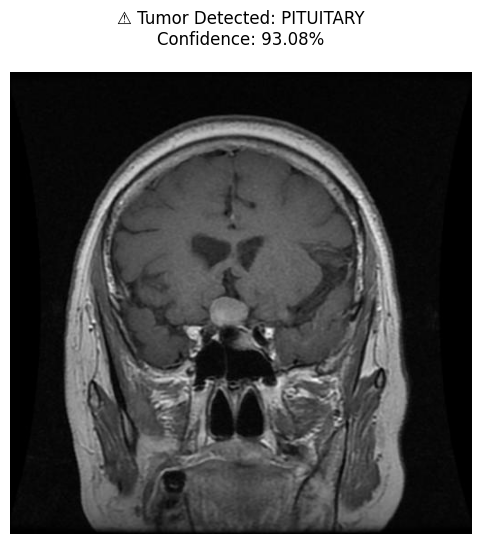

In [ ]:
# Example Test Images
example_images = [
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/glioma/Te-gl_1.jpg',
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/meningioma/Te-aug-me_1.jpg',
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/notumor/Te-no_1.jpg',
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/pituitary/Te-pi_1.jpg'
]

for path in example_images:
    detect_and_display(path, model)

In [ ]:
# Save the model
model.save('resnet50_model.h5')
print("\nModel saved as 'resnet50_model.h5'")


Model saved as 'resnet50_model.h5'


# VGG16 Transfer Learning Model

In [ ]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance

from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, f1_score

import numpy as np

In [ ]:
# ====================== DATASET PATH ======================
train_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Training'
test_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing'
IMAGE_SIZE = 128

In [ ]:
# ====================== LOAD DATASETS ======================
# Load and shuffle train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

In [ ]:
# Load and shuffle test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

Visualizing Random Training Images...


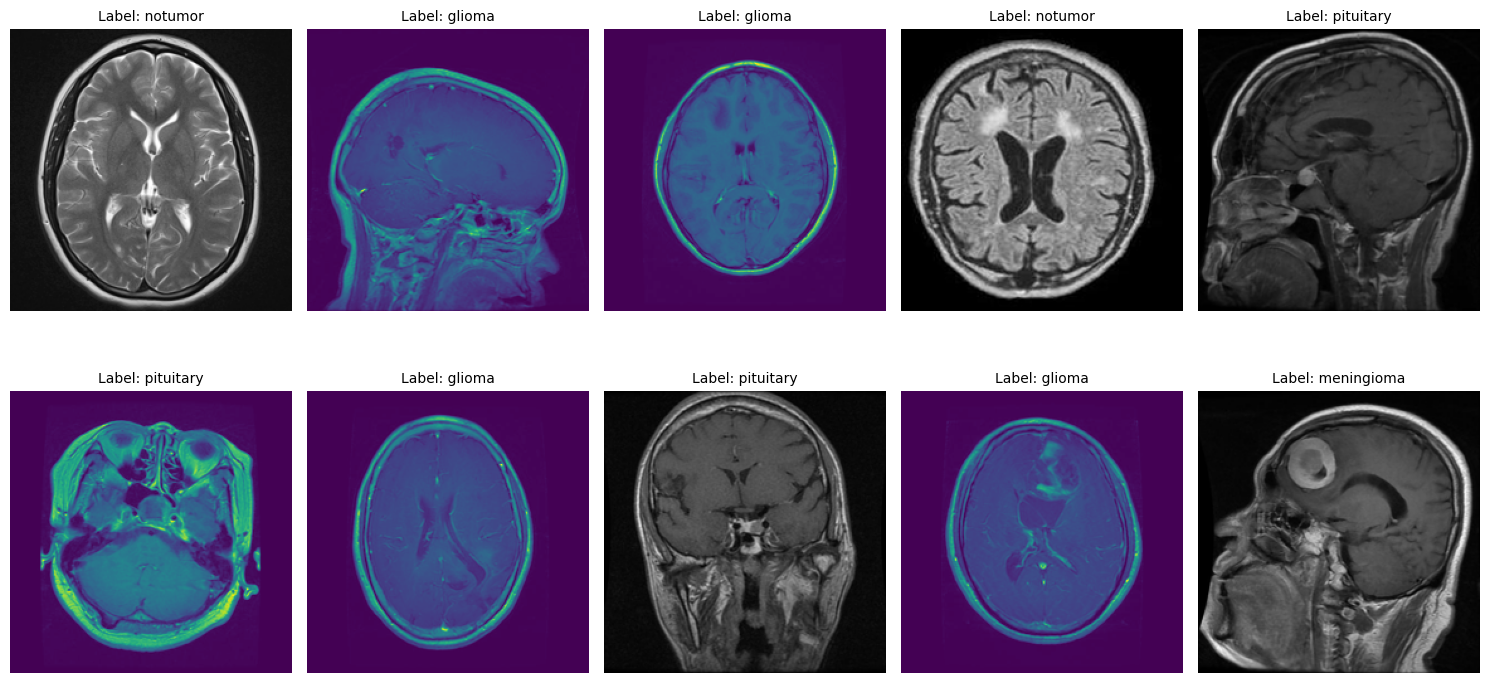

In [ ]:
# ====================== DATA VISUALIZATION ======================
print("Visualizing Random Training Images...")
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ====================== IMAGE PREPROCESSING ======================
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

def encode_label(labels):
    unique_labels = os.listdir(train_dir)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

def datagen(paths, labels, batch_size=20, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [ ]:
# ====================== BUILD VGG16 MODEL ======================
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                   include_top=False,
                   weights='imagenet')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# Unfreeze last few layers
base_model.layers[-4].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-2].trainable = True

In [ ]:
# Build final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

In [ ]:
# Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

In [ ]:
# ====================== TRAIN MODEL ======================
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

print("Training VGG16 model...")
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs,
                    steps_per_epoch=steps)

Training VGG16 model...
Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1218s 4s/step - loss: 0.4606 - sparse_categorical_accuracy: 0.8211
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1232s 4s/step - loss: 0.2418 - sparse_categorical_accuracy: 0.9105
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1241s 4s/step - loss: 0.1615 - sparse_categorical_accuracy: 0.9391
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1245s 4s/step - loss: 0.1092 - sparse_categorical_accuracy: 0.9595
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1198s 4s/step - loss: 0.0817 - sparse_categorical_accuracy: 0.9711


In [ ]:
vgg_acc = acc
vgg_f1 = f1

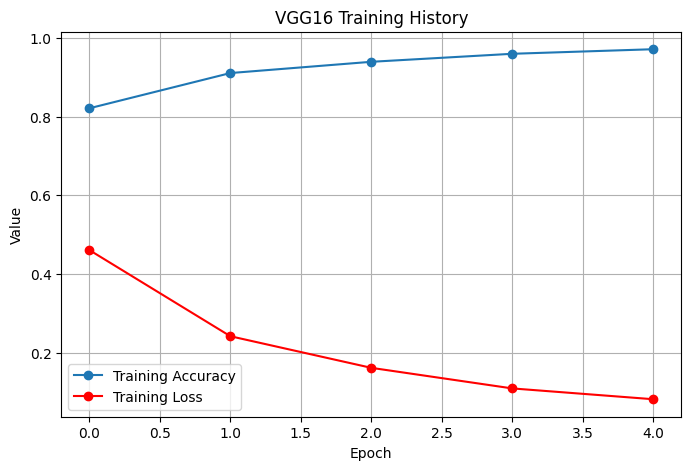

In [ ]:

# ====================== TRAINING HISTORY PLOT ======================
plt.figure(figsize=(8,5))
plt.plot(history.history['sparse_categorical_accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='red')
plt.title('VGG16 Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================== PREDICTION ON TEST DATA ======================
print("Evaluating on Test Data...")
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)
pred_classes = np.argmax(test_predictions, axis=1)

Evaluating on Test Data...
50/50 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step


In [ ]:
# ====================== CLASSIFICATION REPORT ======================
print("\nClassification Report:")
print(classification_report(test_labels_encoded, pred_classes, target_names=os.listdir(train_dir)))

In [ ]:
# ====================== CONFUSION MATRIX ======================
print("\n=== Confusion Matrix ===")
conf_matrix = confusion_matrix(test_labels_encoded, pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=os.listdir(train_dir),
            yticklabels=os.listdir(train_dir))
plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# ====================== ADDITIONAL METRICS ======================
acc = accuracy_score(test_labels_encoded, pred_classes)
f1 = f1_score(test_labels_encoded, pred_classes, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9075
F1 Score: 0.9060


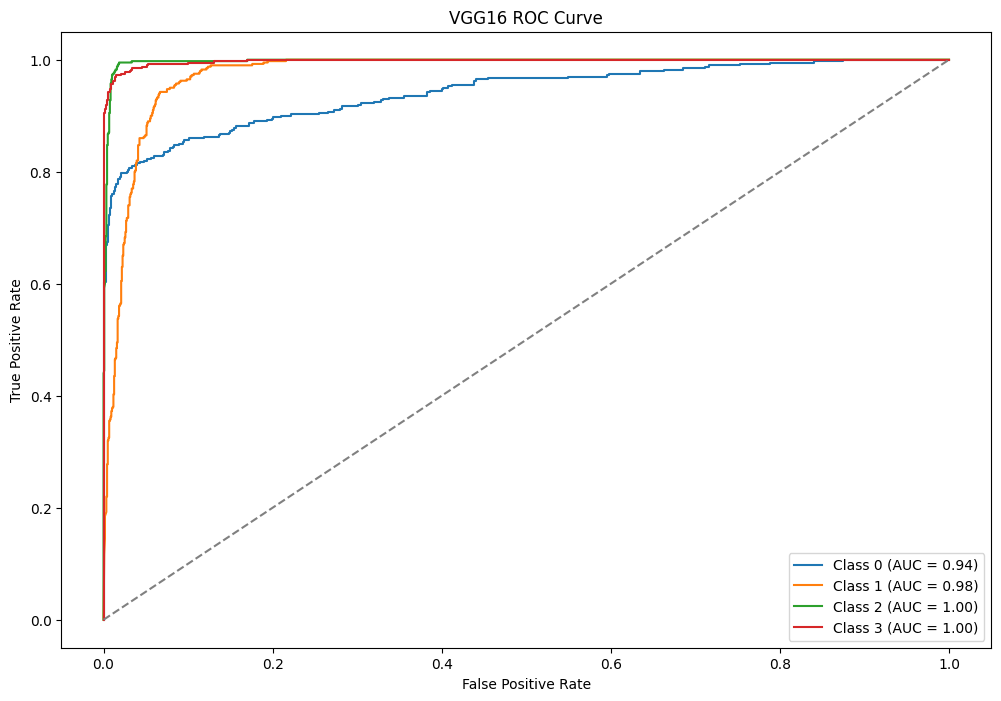

In [ ]:
# ====================== ROC CURVE ======================
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))

plt.figure(figsize=(12, 8))
for i in range(len(os.listdir(train_dir))):
    fpr, tpr, _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("VGG16 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# ====================== SAVE MODEL ======================
model.save('vgg16_brain_tumor_model.h5')
print("Model saved as 'vgg16_brain_tumor_model.h5'")

Model saved as 'vgg16_brain_tumor_model.h5'


In [ ]:
# ====================== MRI TUMOR DETECTION SYSTEM ======================
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions, axis=1)[0]

        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        plt.figure(figsize=(6,6))
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence*100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error:", str(e))


Running example predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step


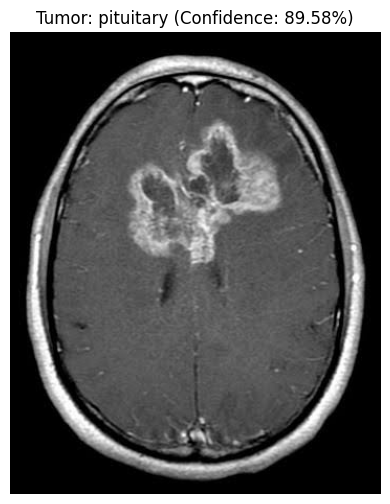

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


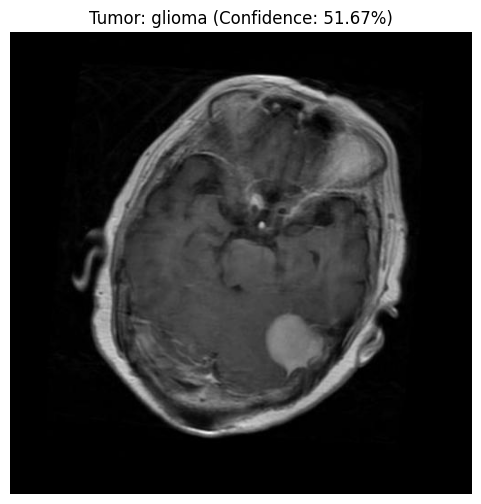

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


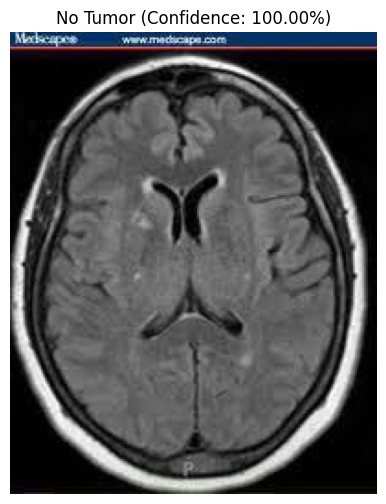

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


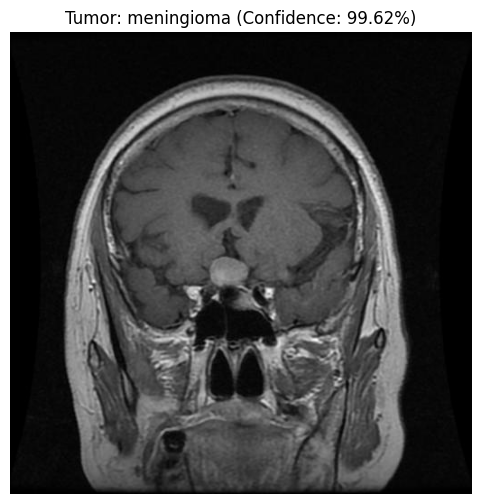

In [ ]:
# Example predictions
print("\nRunning example predictions...")
example_paths = [
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/glioma/Te-gl_1.jpg',
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/meningioma/Te-aug-me_1.jpg',
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/notumor/Te-no_1.jpg',
    '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing/pituitary/Te-pi_1.jpg'
]

for path in example_paths:
    detect_and_display(path, model)

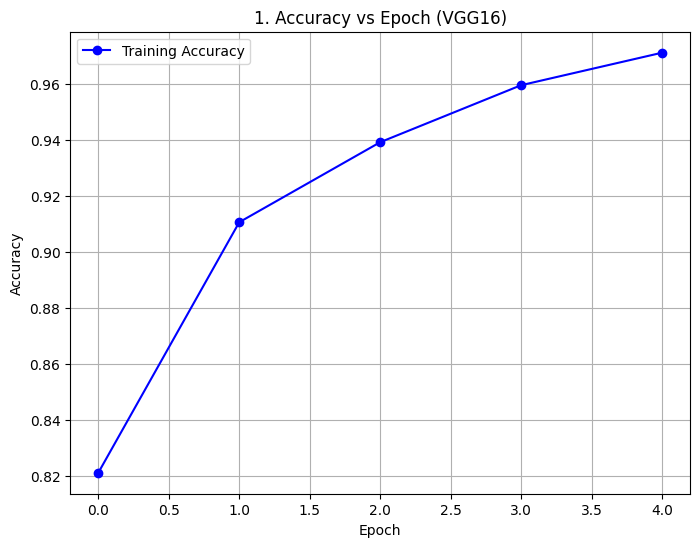

In [ ]:
# 1. Accuracy vs Epoch
plt.figure(figsize=(8, 6))
plt.plot(history.history['sparse_categorical_accuracy'], label='Training Accuracy', marker='o', color='blue')
plt.title('1. Accuracy vs Epoch (VGG16)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

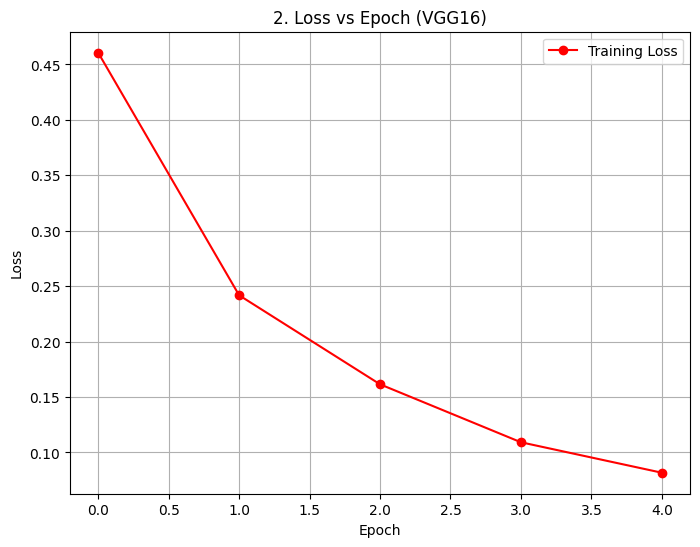

In [ ]:
# 2. Loss vs Epoch
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='red')
plt.title('2. Loss vs Epoch (VGG16)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

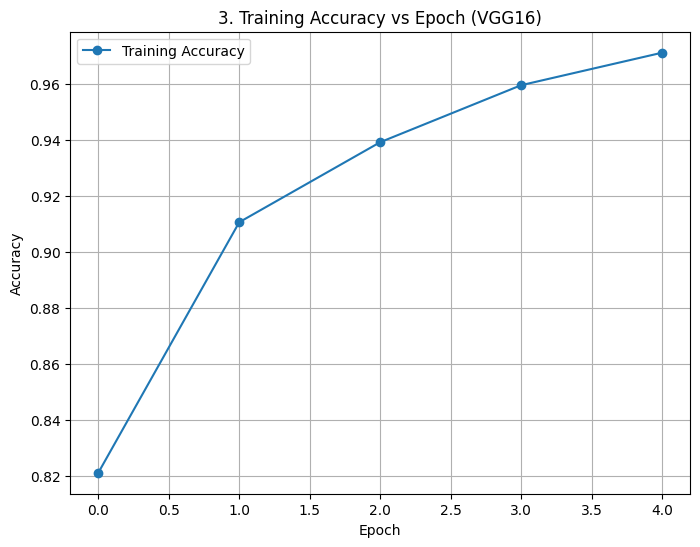

In [ ]:
# 3. Training Accuracy vs Epoch (Note: No validation data in current generator)
plt.figure(figsize=(8, 6))
plt.plot(history.history['sparse_categorical_accuracy'], label='Training Accuracy', marker='o')
plt.title('3. Training Accuracy vs Epoch (VGG16)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

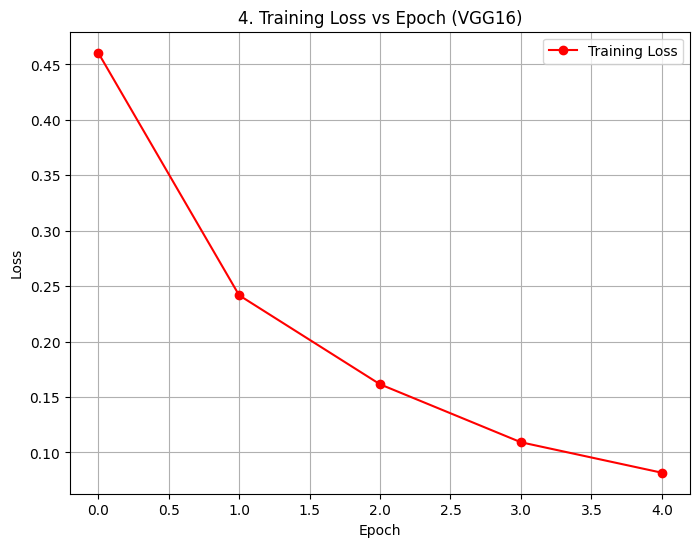

In [ ]:
# 4. Training Loss vs Epoch
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='red')
plt.title('4. Training Loss vs Epoch (VGG16)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

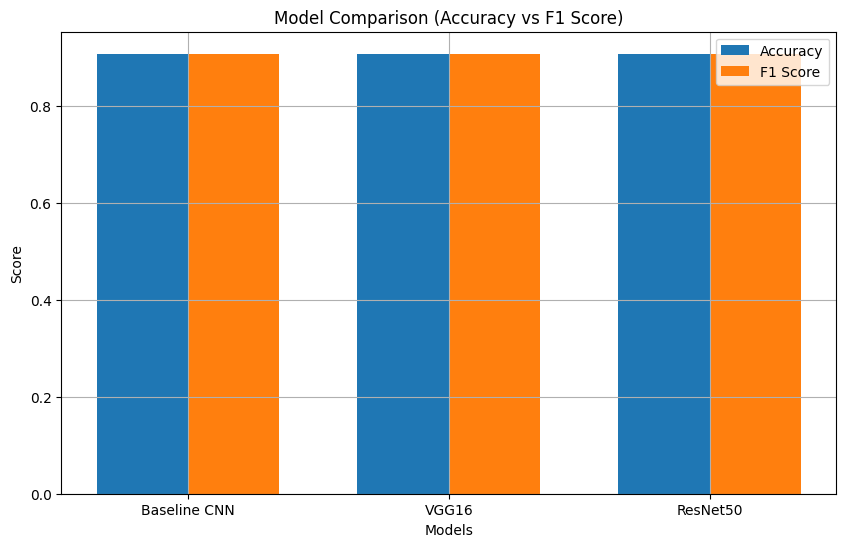

In [ ]:
# ============================================================
# FINAL COMPARISON BAR CHART
# ============================================================

models = ['Baseline CNN', 'VGG16', 'ResNet50']

accuracy = [baseline_acc, vgg_acc, resnet_acc]
f1_scores = [baseline_f1, vgg_f1, resnet_f1]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))

# Accuracy bars
plt.bar(x - width/2, accuracy, width, label='Accuracy')

# F1 Score bars
plt.bar(x + width/2, f1_scores, width, label='F1 Score')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Comparison (Accuracy vs F1 Score)')
plt.xticks(x, models)
plt.legend()
plt.grid(True)

plt.show()